# Dataset

Use the `bank-full.csv` version: 45,211 observations, 16 input features, and the binary target `y`. It is contained in the `bank.zip` download on the UCI page.

You may load it either by downloading `bank.zip` from UCI and uploading the CSV to Colab, or through UCI's `ucimlrepo` package. Using `ucimlrepo` is convenient, but you must still inspect the returned objects and confirm their shapes.

If using the package, the only setup code supplied by this brief is:

In [2]:
!pip -q install ucimlrepo

from ucimlrepo import fetch_ucirepo

bank_marketing = fetch_ucirepo(id=222)
X = bank_marketing.data.features.copy()
y = bank_marketing.data.targets.copy()

In [3]:
X.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN


Do not assume that `y` has the one-dimensional shape expected by every scikit-learn estimator. Inspect it and make an explicit decision if reshaping is necessary.

In [4]:
y.head()

,y
0,no
1,no
2,no
3,no
4,no


# The prediction-time contract

Before modeling, write one paragraph answering this question:
> At what exact moment is this prediction supposed to be made?

For the main experiment, assume the bank wants a prediction **before the phone call has finished**. Therefore, the feature `duration` is forbidden in the main model: ***its value is only known after the call, and a zero-duration call cannot produce a successful subscription***. Including it would give the model information unavailable at the stated prediction time.

Later, you will run one deliberately leaky comparison that includes `duration`. Its purpose is to measure how misleading leakage can be, not to select a final model.

# Learning objectives

By the end, you should be able to:

- inspect an unfamiliar tabular dataset systematically;
- distinguish features, target, identifiers, and prediction-time leakage;
- split data before fitting preprocessing;
- preprocess numerical and categorical features without contaminating the test set;
- establish a naive baseline before interpreting a trained model;
- evaluate an imbalanced binary classifier using more than accuracy;
- compare a valid workflow with a deliberately invalid one;
- describe errors and limitations in plain language.

# Rules and scope

You must:

- use a fixed random seed and record it near the top of the notebook;
- reserve a test set that is used only for final evaluation;
- use a stratified split;
- fit all learned preprocessing on training data only;
- include a naive baseline and logistic regression;
- exclude `duration` from the main model;
- report the required metrics and plots;
- keep a short experiment log;
- finish with the required reflection.

You may:

- use pandas, NumPy, Matplotlib, Seaborn, and scikit-learn;
- use `Pipeline`, `ColumnTransformer`, `OneHotEncoder`, and standard imputers;
- add one optional model after the required baseline and logistic regression;
- consult API documentation and ask for hints.

Do not:

- copy an existing Bank Marketing solution notebook;
- perform broad hyperparameter searches;
- use neural networks;
- use MLflow, Docker, deployment, or cloud services beyond Colab;
- optimize repeatedly against the test set;
- claim that association implies causation;
- keep `duration` in the final deployable feature set.

# Notebook structure and exact checkpoints

Use the numbered headings below in your notebook. Do not move forward from a checkpoint until you can answer its questions.

## 0. Project header and reproducibility

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

RANDOM_SEED = 0
np.random.seed(RANDOM_SEED)

Include:

- project title;
- your name and date;
- prediction-time contract;
- fixed random seed;
- library imports;
- dataset citation and URL.

Checkpoint:

- What is one row intended to represent?
- What is the target?
- What event would happen after a positive prediction?

## 1. Load and establish data shape

Load `X` and `y`, then inspect:

- ✅ Python object types;
- ✅ row and column counts (`df.shape`);
- ✅ column names (`df.columns`);
- ✅ first few rows (`df.head`);
- ✅ target shape and unique values (`df['column_name'].unique()`).

Required assertion:

```python
assert len(X) == len(y)
```

Checkpoint:
- Write the observed shape of `X` (45211, 16).
- Write the observed shape of `y` before (45211, 1) and after any intentional reshaping (45211, ) via `df.squeeze`.
- Confirm that the target contains exactly two semantic classes ("no" and "yes").

In [6]:
print(X.shape) # X has 45211 rows, 16 columns
print(y.shape) # y has 45211 rows, 1 column
assert len(X) == len(y)

(45211, 16)
(45211, 1)


In [7]:
X.head() # Show first 5 rows of X

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN


In [8]:
y.head() # Show first 5 rows of y

,y
0,no
1,no
2,no
3,no
4,no


In [9]:
X.columns # Show all column names of X

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day_of_week', 'month', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome'],
      dtype='object')

In [10]:
y.columns # Show all column names of y

Index(['y'], dtype='object')

In [11]:
y['y'].unique() # Show all unique values of y (only 2 semantic classes comprised of "no", "yes")

array(['no', 'yes'], dtype=object)

In [12]:
y = y.squeeze() # Since Scikit-learn usually receives 1D targets, converting our shape to (n_samples, )
y.shape

(45211,)

## 2. Data audit

pandas dtypes
* X = int64 for numbers and object for semantics.
* y = object for semantics (no and yes).

In [13]:
print("X's dtypes:")
print(X.dtypes)

print("\ny's dtype:")
print(y.dtypes)

X's dtypes:
age             int64
job            object
marital        object
education      object
default        object
balance         int64
housing        object
loan           object
contact        object
day_of_week     int64
month          object
duration        int64
campaign        int64
pdays           int64
previous        int64
poutcome       object
dtype: object

y's dtype:
object


missing values, including whether strings such as unknown encode missing or unavailable information
* `job`, `education`, `contact` and `poutcome` have missing values.
* The latter 3 might be unkown (as in should exist), and `poutcome` might be unavailable (as in probably not existing).

In [14]:
X.isnull().sum()

,0
age,0
job,288
marital,0
education,1857
default,0
balance,0
housing,0
loan,0
contact,13020
day_of_week,0


duplicate rows
* None for `X`.

In [15]:
X.duplicated().sum() # Run a sum of all duplicated rows (did not find any hence returning 0)

np.int64(0)

numerical summaries

In [16]:
X.describe()

,age,balance,day_of_week,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


unique category counts

In [17]:
X.nunique() # Returns the number of unique (distinct) values in a Series or DataFrame

,0
age,77
job,11
marital,3
education,3
default,2
balance,7168
housing,2
loan,2
contact,2
day_of_week,31


suspicious sentinel values, especially `pdays == -1`

In [18]:
X['pdays'].value_counts() # Returns the counts of unique values inside column 'pdays'

,count
pdays,
-1,36954
182,167
92,147
183,126
91,126
...,...
749,1
769,1
587,1


1. target count and target proportion
* 88.3% of samples ended up not proceeding with the marketing.

In [19]:
y.value_counts() / len(y)

,count
y,
no,0.883015
yes,0.116985


2. subscription rate across one categorical feature

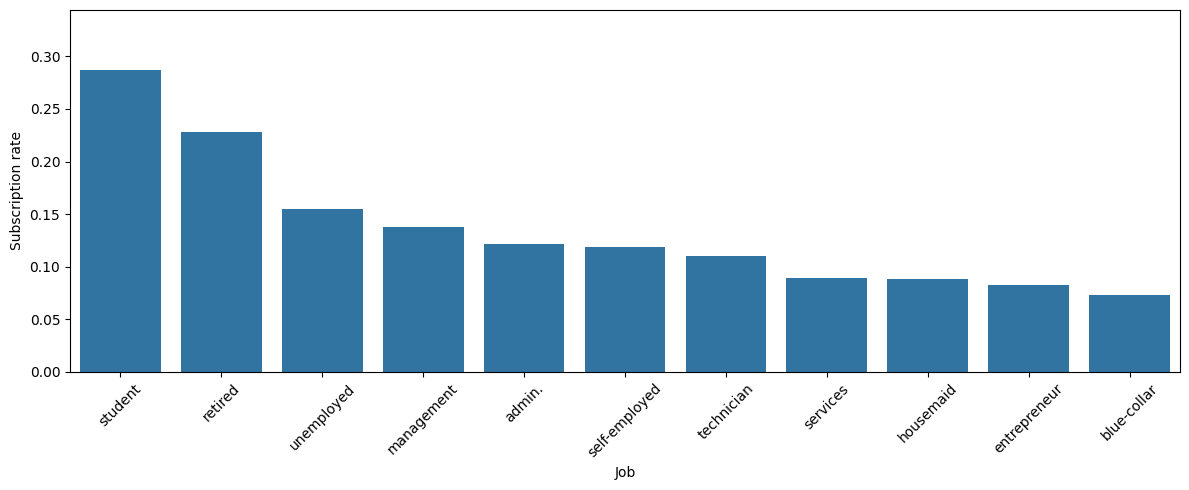

In [20]:
# Counts each y value ("yes" and "no") within each job group.
X.join(y).groupby('job')['y'].value_counts()

# Creates a new DataFrame by joining X and y using their index labels. X and y themselves are not modified.
data = X.join(y)

subscription_rate = (
    data.assign(subscribed=data['y'].eq('yes')) # Returns a new DataFrame with a boolean "subscribed" column: True when y == "yes", otherwise False.
    .groupby('job')['subscribed'] # Groups rows by job and selects the subscribed values from each group.
    .mean() # Calculates the fraction of True values within each job.
    .sort_values(ascending=False) # Sorts jobs from highest subscription rate to lowest.
    .reset_index() # Converts job from the index into a regular column, producing a DataFrame with job and subscribed columns.
)

plt.figure(figsize=(12, 5)) # Creates a figure that is 12 inches wide and 5 inches tall.
ax = sns.barplot(
    # Uses job for the horizontal positions and subscription rate for bar heights.
    data=subscription_rate,
    x='job',
    y='subscribed',
)
ax.set_ylabel("Subscription rate")
ax.set_xlabel("Job")
ax.set_ylim(0, subscription_rate['subscribed'].max() * 1.2) # Starts the vertical axis at zero and leaves 20% extra space above the tallest bar.

plt.xticks(rotation=45) # Rotates job labels to reduce overlap.
plt.tight_layout() # Adjusts spacing so labels are not cut off.
plt.show()

3. distribution of one numerical feature, separated by target where useful

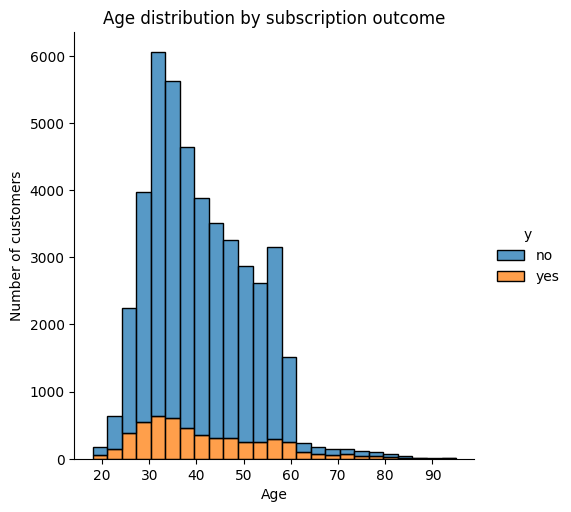

In [21]:
data = X.join(y)

sns.displot(
    data=data,
    x='age',
    hue='y', # Separates observations by color
    bins=25,
    multiple='stack',
    stat='count',
)
plt.xlabel('Age')
plt.ylabel('Number of customers')
plt.title('Age distribution by subscription outcome')
plt.show()

Create a compact audit that examines:

- ✅ pandas dtypes;
- ✅ missing values, including whether strings such as unknown encode missing or unavailable information;
- ✅ duplicate rows;
- ✅ numerical summaries;
- ✅ unique category counts;
- ✅ suspicious sentinel values, especially `pdays == -1`;
- ✅ target count and target proportion.

Do not automatically delete every duplicate or replace every unknown. First decide what each value might mean in this dataset.

Required visualizations:

1. ✅ target-class counts or proportions;
2. ✅ subscription rate across one categorical feature;
3. ✅ distribution of one numerical feature, separated by target where useful.

Checkpoint:

- Is the target balanced enough for accuracy to be meaningful by itself?
> No. The target is substantially imbalanced—about 88% “No” and 12% “Yes.” A model that always predicts “No” could achieve roughly 88% accuracy while never identifying a subscriber. Accuracy should therefore be considered alongside precision, recall, F1, PR-AUC, and the confusion matrix.

- Which columns are numerical in storage but might represent categories or special codes?
> In `bank-full.csv`, day is numeric but represents the day of the month, so its calendar meaning may require special treatment. `pdays` is numeric but includes `-1` as a sentinel code. `campaign` and `previous` are discrete counts, although they are still genuinely numerical.

- What does `pdays == -1` appear to mean?
> It means the client was not previously contacted in an earlier campaign. `pdays` is the number of days since the client was last contacted in a previous campaign.

- Are duplicate records necessarily erroneous here? Explain your decision.
> No. Identical rows could represent separate campaign contacts or different clients who happen to share the same recorded attributes. Because the dataset lacks a unique client/contact identifier, exact duplicates cannot automatically be proven erroneous. Record their number, but do not remove them without stronger evidence.

## 3. Define the valid feature set

Create the main feature table without `duration`. Separate its columns into numerical and categorical lists, and verify that every feature appears in exactly one list.

In [22]:
# Drop duration in X_main
X_main = X.drop(columns=['duration'])
assert "duration" not in X_main.columns

# Create a copy just for numeric features
numeric_features = X_main[['age', 'balance', 'pdays', 'previous']]

# Create a copy just for categorical features
categorical_features = X_main[['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'day_of_week', 'month', 'campaign', 'poutcome']]

# Assert that numerical_features does not equal categorical features, and that they are both in X_main
assert set(numeric_features).isdisjoint(categorical_features)
assert set(numeric_features) | set(categorical_features) == set(X_main.columns)

Checkpoint:

- Why is `duration` leakage under this project's prediction-time contract?
> The model must make its prediction before the phone call has finished. `duration` is only known after the call ends. Using it would give the model future information that would not be available at prediction time, producing misleadingly good results.

- Which other columns might become unavailable under a different prediction moment?
> It depends on when the prediction is made. If it is made before the campaign begins, call-related fields such as `contact`, `day`, `month`, and `campaign` might not yet be known. If the prediction is made before any previous campaigns, `pdays`, `previous`, and `poutcome` would also be unavailable.

- Why should column roles be chosen by meaning rather than dtype alone?
> A column’s storage type does not always describe what it represents. For example, `pdays` is numeric but uses `-1` as a special code meaning the client was not previously contacted. Conversely, a value stored as text may represent ordered information. We should inspect each column’s real-world meaning before deciding how to preprocess it.

## 4. Make the train/test split

Create one stratified train/test split. A 20% test fraction is appropriate. Use the fixed seed declared in Section 0.

After splitting, display:

- all four shapes;
- positive-class proportion in the full target, training target, and test target;
- confirmation that row indices do not overlap.

In [23]:
# Split X_main instead since X contains duration, which we don't want in the model (prediction has to be made before call finish)
# Add stratify=y to preserve the target proportions
X_train, X_test, y_train, y_test = train_test_split(X_main, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)

# Display all 4 shapes
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

# Positive-class proportions
print("Full:", (y == "yes").mean())
print("Training:", (y_train == "yes").mean())
print("Test:", (y_test == "yes").mean())

# No overlapping row indices
assert set(X_train.index).isdisjoint(X_test.index)
assert set(y_train.index).isdisjoint(y_test.index)

(36168, 15)
(9043, 15)
(36168,)
(9043,)
Full: 0.11698480458295547
Training: 0.11698186241981863
Test: 0.11699657193409267


Checkpoint:

- Why stratify?
> In `train_test_split`, the `stratify` parameter ensures that the training and testing sets have the same **proportion of classes (or labels)** as the original dataset. This is particularly useful when dealing with **imbalanced datasets**, where some classes are underrepresented.
> Without stratification, random splitting might lead to training or test sets with very few (or even zero) samples of a minority class, which can bias the model.

- Why must the test set remain untouched during model and threshold decisions?
> The test set must remain untouched so that it provides an unbiased evaluation of how the final workflow performs on unseen data. If it is used to select models, preprocessing choices, hyperparameters, or classification thresholds, those decisions may become tailored to the test set, making the final results overly optimistic.

- What information is allowed to be learned from the training set?
> The workflow may learn preprocessing statistics and relationships from the training data only. This includes imputation values, category encodings, scaling statistics, model coefficients, and relationships between valid input features and the target. **It must not learn from the test set, and it must not use features such as duration that are unavailable at the intended prediction time.**

## 5. Establish a naive baseline

Train a `DummyClassifier` that always predicts the most frequent class. Evaluate it on the held-out test set.

Record:

- accuracy;
- precision;
- recall;
- F1 score;
- confusion matrix.

In [24]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

# Create an train the baseline
dummy_model = DummyClassifier(strategy="most_frequent") # Always predict the most frequent class
dummy_model.fit(X_train, y_train)

# Predict the test-set outcomes
y_pred_dummy = dummy_model.predict(X_test)

# Evaluate the positive ("yes") class
accuracy = accuracy_score(y_test, y_pred_dummy)
precision = precision_score(y_test, y_pred_dummy, pos_label="yes", zero_division=0)
recall = recall_score(y_test, y_pred_dummy, pos_label="yes", zero_division=0)
f1 = f1_score(y_test, y_pred_dummy, pos_label="yes", zero_division=0)
matrix = confusion_matrix(y_test, y_pred_dummy, labels=["no", "yes"])

# Displays
print("Accuracy:", accuracy) # The proportion of all predictions that are correct.
print("Precision:", precision) # When a prediction is made, how often is it correct?
print("Recall:", recall) # Of all actual positive cases, the proportion correctly predicted as positive.
print("F1 score:", f1) # A single score that balances precision and recall.
print("Confusion matrix:") # A table comparing actual and predicted classes, showing correct and incorrect predictions.
print(matrix)

Accuracy: 0.8830034280659074
Precision: 0.0
Recall: 0.0
F1 score: 0.0
Confusion matrix:
[[7985    0]
 [1058    0]]


Checkpoint:

* Why can this baseline achieve apparently respectable accuracy?
> Because the dataset contains many more “No” outcomes than “Yes” outcomes. By always predicting “No,” the baseline correctly classifies most records.

* What does it do for the positive class?
> Nothing useful: it never predicts “Yes,” so it misses every actual positive case.

* Which metric exposes its main weakness most directly?
> Recall for the positive class exposes it most directly: recall is 0 because every positive case is a false negative. The positive-class F1 score is also 0, but recall identifies the specific weakness more directly.

## 6. Build the preprocessing and logistic-regression pipeline

Build a scikit-learn workflow that:

- transforms numerical and categorical columns appropriately;
- handles any missing-value policy you chose;
- one-hot encodes categorical features while tolerating unseen categories;
- trains logistic regression;
- prevents learned preprocessing from being fit on test data.

Use standard library components rather than manually creating dummy columns before the split. Keep the first model simple. If convergence warnings occur, investigate scaling and/or the iteration limit instead of suppressing warnings.

| Tool | Purpose |
|---|---|
| ColumnTransformer | Sends different columns through different preprocessing |
| SimpleImputer | Fills missing values |
| LogisticRegression | Learns to predict "no" or "yes" |
| Pipeline | Connects processing and modeling steps in order |
| OneHotEncoder | Converts categories into numeric indicators |
| StandardScaler | Rescales numerical columns |

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")), # For every missing value, fill it with the median value
    ("scaler", StandardScaler()), # Standardize all values based on training mean and std
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")), # For every missing value, replace with the most common training value (e.g. missing jobs are assumed to be management)
    ("onehot", OneHotEncoder(handle_unknown="ignore")), # Converts categories into numeric indicator columns (e.g. 1 for job_management) and continue prediction if the model sees a missing categorical value
])

numeric_features = ['age', 'balance', 'pdays', 'previous']
categorical_features = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'day_of_week', 'month', 'campaign', 'poutcome']

preprocessor = ColumnTransformer([ # Divide the training batches into numeric columns (median -> scaling) and categorical columns (mode -> one hot)
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

# Connects preprocessing to classification: Raw DataFrame -> preprocessor -> numeric feature matrix -> logistic regression -> predicted class/probability
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000)),
])

# Model undergoes training
# 1. Calculates numerical medians.
# 2. Calculates numerical means and standard deviations.
# 3. Calculates the most frequent categorical values.
# 4. Learns the categories used by the one-hot encoder.
# 5. Transforms X_train.
# 6. Trains logistic regression on the transformed training data.
model.fit(X_train, y_train)

# The fitted pipeline:
# 1. Applies the previously learned preprocessing to X_test.
# 2. Passes the transformed test rows to logistic regression.
# 3. Returns a class for each row:
y_pred = model.predict(X_test)

y_probability = model.predict_proba(X_test)[:, 1] # predict_proba() returns two probabilities for every row—one for each class.

Checkpoint:

- Which pipeline steps learn state during `.fit()`?
> The numerical imputer learns the median of each numerical column, and `StandardScaler` learns each column’s mean and standard deviation. The categorical imputer learns the most frequent value in each categorical column, while `OneHotEncoder` learns which categories exist. Finally, `LogisticRegression` learns the coefficients and intercept used to make predictions.

- On which rows is that state learned?
> All preprocessing statistics, categories, and model parameters are learned only from the training rows because the pipeline is fitted using `model.fit(X_train, y_train)`. Nothing is learned from the test rows.

- What happens if a category exists in the test set but not the training set?
> Because `OneHotEncoder` uses `handle_unknown="ignore"`, an unseen test category does not cause an error. Its one-hot values for that feature are all set to zero. The model can still make a prediction using the other available features, although it has not learned a specific effect for that unseen category.

- Why is a pipeline safer than preprocessing the whole dataframe first?
> A pipeline ensures that learned preprocessing—such as medians, most-frequent values, scaling statistics, and category mappings—is fitted only on the training data. Preprocessing the entire DataFrame before splitting could allow information from the test set to influence those transformations, causing data leakage and making the test results overly optimistic.

## 7. Evaluate the main model

Evaluate logistic regression on the untouched test set.

Required outputs:

- accuracy;
- precision for the positive class;
- recall for the positive class;
- F1 score for the positive class;
- ROC-AUC using predicted probabilities, not hard labels;
- confusion matrix with readable class labels;
- one threshold-independent curve: ROC or precision-recall.

Also show the number of true negatives, false positives, false negatives, and true positives, then explain each in the bank's context.

In [26]:
from sklearn.metrics import(
    # accuracy_score, ALREADY IMPORTED
    # precision_score, ALREADY IMPORTED
    # recall_score, ALREADY IMPORTED
    # f1_score, ALREADY IMPORTED
    # confusion_matrix, ALREADY IMPORTED
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    pos_label='yes',
    zero_division=0,
)

recall = recall_score(
    y_test,
    y_pred,
    pos_label='yes',
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    pos_label='yes',
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_probability,
)

# Display metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 score:", f1)
print("ROC-AUC:", roc_auc) # How well the model generally ranks subscribers above non-subscribers across possible thresholds.

Accuracy: 0.8921817980758597
Precision: 0.6416382252559727
Recall: 0.1776937618147448
F1 score: 0.2783123612139156
ROC-AUC: 0.7619302733267599


True negatives: 7880
False positives: 105
False negatives: 870
True positives: 188


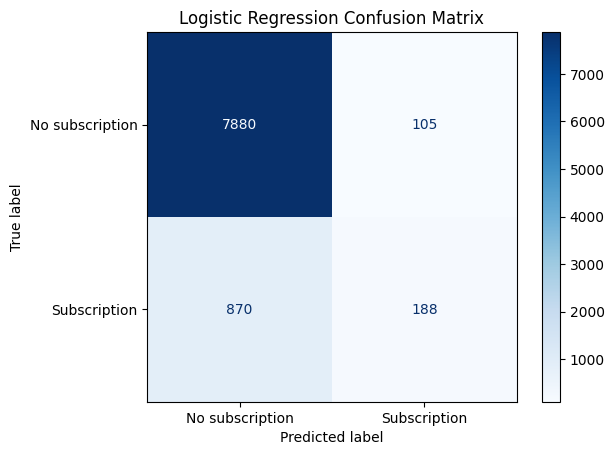

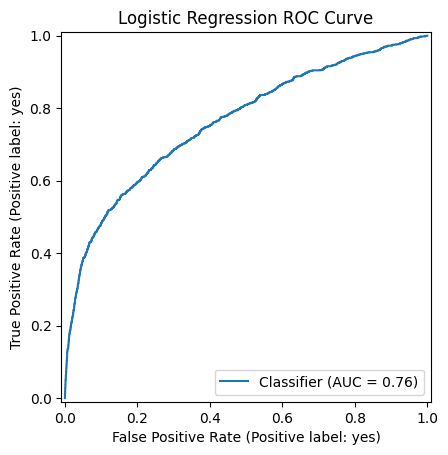

In [27]:
matrix = confusion_matrix(
    y_test,
    y_pred,
    labels=['no', 'yes'],
)

tn, fp, fn, tp = matrix.ravel()

print("True negatives:", tn)
print("False positives:", fp)
print("False negatives:", fn)
print("True positives:", tp)

ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=['No subscription', 'Subscription'],
).plot(cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Shows how the model’s ability to detect subscribers changes as you change the probability threshold used to predict "yes"
# A curve near the upper-left corner is better because it represents a high proportion of subscribers found & a low proportion of non-subscribers incorrectly flagged
RocCurveDisplay.from_predictions(
    y_test,
    y_probability,
    pos_label='yes',
)
plt.title("Logistic Regression ROC Curve")
plt.show()

Checkpoint:

- Did the model improve over the dummy baseline in a meaningful way?
> Yes, the logistic-regression model improved over the dummy baseline because it can identify at least some positive cases, whereas the dummy model predicts every case as negative and has zero positive-class recall and F1. However, the logistic-regression model still produces more false negatives than true positives, so it misses more than half of the actual positive cases. The improvement is meaningful but limited.

- Which error is more costly: calling someone unlikely to subscribe, or failing to call someone who would? State an assumption rather than claiming a universal answer.
> I will assume that phone calls are relatively inexpensive and that obtaining a new subscription is valuable. Under this assumption, failing to call someone who would subscribe—a false negative—is more costly because it represents a lost potential subscription. If calls were expensive or unwanted calls caused serious customer dissatisfaction, false positives could instead be more costly.

- Would you choose a model using accuracy alone? Why or why not?
> No. Because the target is heavily imbalanced, a model can achieve high accuracy by predicting the majority negative class while identifying few or no positive cases. I would also examine positive-class precision, recall, F1, ROC-AUC, and the confusion matrix. The most important metric would depend on the relative cost of false positives and false negatives.

- What does ROC-AUC mean here without using the phrase "the model is X% accurate"?
> ROC-AUC measures how well the model ranks positive cases above negative cases across possible classification thresholds. For example, an ROC-AUC of 0.80 means that when one positive case and one negative case are selected at random, the model has about an 80% chance of assigning the positive case a higher predicted score (or the model's measure of confidence for its own answer).

## 8. Threshold experiment

The default decision threshold is commonly 0.5. Compare it with at least two other thresholds using the same trained model. Do not retrain for each threshold.

Create a small table containing, for every threshold:

- threshold;
- predicted-positive count;
- precision;
- recall;
- F1;
- false positives;
- false negatives.

In [28]:
thresholds = [0.30, 0.50, 0.70]

threshold_results = []

for threshold in thresholds:
  # Convert probabilities into yes/no predictions
  threshold_predictions = np.where( # The "if" function of numpy that takes a condition and the returns for True and False, np.where(condition, value_if_true, value_if_false)
      y_probability >= threshold,
      "yes",
      "no",
  )

  # Calculate the confusion matrix
  matrix = confusion_matrix( # Compare the threshold-based predictions with the true test labels
      y_test,
      threshold_predictions,
      labels=['no', 'yes'],
  )

  tn, fp, fn, tp = matrix.ravel() # Flatten the 2x2 confusion matrix and assign its 4 elements

  # Store this threshold's results
  threshold_results.append({
      'threshold':threshold,
      'predicted_positive_count': (threshold_predictions == 'yes').sum(),
      'precision':precision_score(y_test, threshold_predictions, pos_label='yes', zero_division=0),
      'recall':recall_score(y_test, threshold_predictions, pos_label='yes', zero_division=0),
      'f1':f1_score(y_test, threshold_predictions, pos_label='yes', zero_division=0),
      'false_positives': fp,
      'false_negatives': fn,
  })

threshold_table = pd.DataFrame(threshold_results)
threshold_table

,threshold,predicted_positive_count,precision,recall,f1,false_positives,false_negatives
0,0.3,616,0.535714,0.311909,0.394265,286,728
1,0.5,293,0.641638,0.177694,0.278312,105,870
2,0.7,124,0.725806,0.085066,0.152284,34,968


Checkpoint:

- What changes mechanically when the threshold changes?
> The trained model and its probability scores do not change. Only the cutoff used to convert positive-class probabilities into `"yes"` or `"no"` predictions changes. Lowering the threshold causes more cases to be predicted as positive, while raising it causes fewer cases to be predicted as positive. This changes precision, recall, F1, false positives, and false negatives.

- Which threshold would you recommend under your stated business-cost assumption?
> I assume that missing a potential positive case is more costly than evaluating or contacting an extra negative case. Under that assumption, I would recommend a threshold of `0.3` because it increases recall and reduces false negatives while maintaining an acceptable number of false positives. This is a preliminary choice based on the thresholds examined, not a production recommendation.

- Why is test-set threshold selection methodologically questionable?
> Selecting a threshold based on its test-set performance allows information from the test set to influence the final workflow. The chosen threshold could become tailored to this particular test set, so evaluating it on the same test set would produce an overly optimistic estimate of performance on genuinely unseen data.

- In a larger project, what additional split would you introduce?
> I would divide the data into training, validation, and test sets. The training set would be used to fit the preprocessing and model. The validation set would be used to compare models and choose the decision threshold. After all decisions were finalized, the untouched test set would be used once for the final evaluation.

This is a learning exercise, so you may display test-set threshold comparisons. Explicitly acknowledge that a real threshold would be selected using validation data and evaluated once on the test set.

## 9. Deliberately leaky variant

Build one comparison pipeline using the same split logic but including `duration`. Keep other major choices as similar as possible.

Compare the valid and leaky models in one table. Include at least ROC-AUC, recall, F1, and a short statement about deployability.

In [29]:
# Retrieve the same training and test rows from the original feature table. Unlike X_main, the original X still contains duration.
X_train_leaky = X.loc[X_train.index].copy()
X_test_leaky = X.loc[X_test.index].copy()

# Confirm that duration is present only in the leaky feature tables.
assert 'duration' in X_train_leaky.columns
assert 'duration' in X_test_leaky.columns
assert 'duration' not in X_train.columns
assert 'duration' not in X_test.columns

# Keep the original feature roles, but add duration as numerical.
leaky_numeric_features = numeric_features + ['duration']
leaky_categorical_features = categorical_features.copy()

# Apply the same preprocessing policies used by the valid model.
leaky_preprocessor = ColumnTransformer([ # Transforms numeric columns into medians and categoricals into modes (most frequent occurence)
    ('numeric', numeric_pipeline, leaky_numeric_features),
    ('categorical', categorical_pipeline, leaky_categorical_features),
])

# Build a separate model so the valid model is not overwritten.
leaky_model = Pipeline([
    ('preprocessor', leaky_preprocessor),
    ('classifier', LogisticRegression(max_iter=1000)),
])

# Train the leaky model on the same training rows.
leaky_model.fit(X_train_leaky, y_train)

# Make predictions on the same test rows.
leaky_y_pred = leaky_model.predict(X_test_leaky)

# Get the predicted probability of the positive class.
leaky_yes_index = list(leaky_model.classes_).index('yes')

leaky_y_probability = leaky_model.predict_proba(X_test_leaky)[:,leaky_yes_index]

In [30]:
# Recalculate the valid model’s metrics explicitly so the comparison table does not depend on variables from earlier cells:

valid_roc_auc = roc_auc_score(y_test, y_probability)
valid_recall = recall_score(y_test, y_pred, pos_label='yes', zero_division=0)
valid_f1 = f1_score(y_test, y_pred, pos_label='yes', zero_division=0)

leaky_roc_auc = roc_auc_score(y_test, leaky_y_probability)
leaky_recall = recall_score(y_test, leaky_y_pred, pos_label='yes', zero_division=0)
leaky_f1 = f1_score(y_test, leaky_y_pred, pos_label='yes', zero_division=0)

# Create the comparison table

model_comparison = pd.DataFrame([
    {
        'model': 'Valid logistic regression',
        'duration_included': 'No',
        'roc_auc': valid_roc_auc,
        'recall': valid_recall,
        'f1': valid_f1,
        'deployability': ('Valid for the stated prediction time'),
    },
    {
        'model': 'Leaky logistic regression',
        'duration_included': 'Yes',
        'roc_auc': leaky_roc_auc,
        'recall': leaky_recall,
        'f1': leaky_f1,
        'deployability': ('Not deployable: duration is unavailable before the call ends'),
    },
])
model_comparison

,model,duration_included,roc_auc,recall,f1,deployability
0,Valid logistic regression,No,0.761930,0.177694,0.278312,Valid for the stated prediction time
1,Leaky logistic regression,Yes,0.905731,0.345936,0.452970,Not deployable: duration is unavailable before...


Checkpoint:

- Did the leaky model appear stronger?
> Yes. The leaky model achieved higher ROC-AUC, recall, and F1 scores than the valid model. Including duration gave it information strongly associated with the outcome, making its offline test performance appear better.

- Why does better offline performance not make it the correct model?
> We cannot use a model that includes / relies on `duration` because it is not present ahead / during the banking promotion call.

- Give one example outside this dataset of a feature that could reveal the outcome because it is recorded too late.
> Merchandise ARPU at a concert to determine if the user would attend the concert (not reliable since users make purchase decisions during / after concerts, not ahead of it which is what we are trying to measure).

## 10. Error analysis

Create dataframes for false positives and false negatives by joining predictions back to the original test rows. Inspect a small sample and compare at least two feature distributions or category rates between:

- correctly predicted positives and false negatives; or
- correctly predicted negatives and false positives.

Do not invent a causal story. Describe patterns as observations and propose what additional information would be required to test an explanation.

In [36]:
test_results = X_test.copy()

test_results['actual'] = y_test
test_results['predicted'] = y_pred
test_results['probability_yes'] = y_probability

false_negatives = test_results[
    (test_results['actual'] == 'yes') & (test_results['predicted'] == 'no')
]

true_positives = test_results[
    (test_results['actual'] == 'yes') & (test_results['predicted'] == 'yes')
]

pd.DataFrame(
    {
        'missed_subscribers': false_negatives['age'].describe(),
        'caught_subscribers': true_positives['age'].describe(),
    }
)

,missed_subscribers,caught_subscribers
count,870.000000,188.000000
mean,40.851724,43.276596
std,12.335074,16.168831
min,18.000000,19.000000
25%,31.000000,30.000000
50%,37.000000,39.000000
75%,49.000000,55.000000
max,86.000000,93.000000


Checkpoint:

* Is there an obvious subgroup where the model struggles?
> At threshold `0.5`, the model misses about 82% of actual subscribers. This shows difficulty identifying the positive class. However, I need to compare feature distributions between false negatives and true positives before identifying a specific subgroup where it struggles.

* Could the pattern be caused by sample size?
> A pattern within a small subgroup could reflect random variation. I should report the number of observations in each group alongside its proportions. The overall class imbalance alone does not establish that the dataset is biased or explain the errors.

* What new data might help distinguish competing explanations?
> More labeled examples from the subgroup where errors concentrate, collected from later campaigns, would help check whether the pattern persists. Information recorded before the call, such as prior product interest, could help investigate whether the current features lack useful signals.

## 11. Experiment log

Maintain a compact table like this:

In [38]:
experiment_log = []

runs = [
    (0, "Main", "Dummy", "Majority baseline", y_pred_dummy, None, "Yes"),
    (1, "Main", "Logistic regression", "Initial valid pipeline", y_pred, y_probability, "Yes"),
    (2, "Main + duration", "Logistic regression", "Deliberately leaky", leaky_y_pred, leaky_y_probability, "No"),
]

for run, features, model_name, change, predictions, probabilities, valid in runs:
  experiment_log.append({
      "Run": run,
      "Feature policy": features,
      "Model": model_name,
      "Key change": change,
      "Accuracy": accuracy_score(y_test, predictions),
      "Precision": precision_score(y_test, predictions, pos_label='yes', zero_division=0),
      "Recall": recall_score(y_test, predictions, pos_label='yes', zero_division=0),
      "F1": f1_score(y_test, predictions, pos_label='yes', zero_division=0),
      "ROC-AUC": (roc_auc_score(y_test, probabilities) if probabilities is not None else np.nan),
      "valid at prediction time?": valid,
  })

experiment_log = pd.DataFrame(experiment_log)

experiment_log.style.format( # pandas method to stylize tables via Styler object
    {metric: "{:.4f}" for metric in ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']},
    na_rep='N/A',
)

,Run,Feature policy,Model,Key change,Accuracy,Precision,Recall,F1,ROC-AUC,valid at prediction time?
0,0,Main,Dummy,Majority baseline,0.8830,0.0000,0.0000,0.0000,N/A,Yes
1,1,Main,Logistic regression,Initial valid pipeline,0.8922,0.6416,0.1777,0.2783,0.7619,No
2,2,Main + duration,Logistic regression,Deliberately leaky,0.9022,0.6559,0.3459,0.4530,0.9057,No


## 12. Final report

1. **Problem:** prediction target and prediction moment.
> The goal was to predict whether a contacted client would subscribe to a term deposit. Predictions must be made before the phone call finishes, so the main model excludes the final call duration.

2. **Data:** size, feature types, target balance, and important quality findings.
> The dataset contained 45,211 rows and 16 input features, including numerical values such as age and balance and categories such as job and education. About 11.7% of outcomes were subscriptions. Several categorical columns contained missing values, and no duplicate feature rows were found. The value `pdays = -1` indicated no previous campaign contact.

3. **Method:** split, preprocessing, baseline, and main model.
>  I used an 80/20 stratified train/test split with random seed 0. Numerical features were imputed using training medians and standardized. Categorical features were imputed using their most frequent training values and one-hot encoded. I compared a majority-class dummy baseline with logistic regression, using a pipeline to fit preprocessing only on training data.

4. **Results:** comparison against baseline with the metrics that matter.
> The dummy baseline achieved 88.3% accuracy but identified no subscribers. Logistic regression achieved 89.2% accuracy, 64.2% precision, 17.8% recall, an F1 score of 0.278, and ROC-AUC of 0.762. At threshold `0.5`, it correctly identified 188 subscribers and missed 870. This was an improvement over the baseline, but recall remained low.

5. **Leakage finding:** what happened when `duration` was included and why that
   result is invalid for the main scenario.
> Including `duration` increased ROC-AUC to 0.906, recall to 34.6%, and F1 to 0.453. However, final call duration is unavailable at the intended prediction time. The stronger scores therefore do not justify using this model for the stated task.

6. **Error analysis:** one observed pattern, carefully stated.
> At threshold `0.5`, the valid model missed about 82% of actual subscribers. This establishes difficulty detecting the positive class, but does not establish that class imbalance caused the errors. Comparing age distributions between false negatives and true positives, I did not observe a clear difference. These comparisons did not identify an obvious subgroup where the model struggled, and they do not establish why the errors occurred.

7. **Limitations:** at least three limitations.
> The model had low recall at the default threshold. Threshold comparisons used test data, so they cannot establish an independently validated threshold choice. A random split does not show how well the model would perform on future campaigns. Missing categorical information and the chosen imputation policy may also limit what the model can learn.

8. **Recommendation:** whether the current work is good enough for further
   investigation—not whether it should immediately be deployed.
> The model is worth further investigation because it identifies some subscribers and ranks outcomes better than chance. Under the assumption that missing a subscriber costs more than an extra call, threshold 0.3 was more promising than 0.5 or 0.7 among those examined. A next step would be to choose the threshold using validation data and evaluate the finalized workflow on an untouched test set.

9. **What I now understand:** five concrete statements about skills or concepts that became clearer.
> - High accuracy can hide a model that misses the minority class.
> - A feature is leakage when it provides information unavailable at prediction time.
> - Learned preprocessing must be fitted on training data only.
> - Changing a threshold changes the predicted labels without retraining the model.
> - Error analysis compares mistaken and correct predictions without assuming that observed differences explain their causes.

# Minimum completion rubric

The project is complete only when all required rows below are satisfied.

| Area | Completion standard |
|---|---|
| Problem framing | Prediction moment is explicit and determines feature availability. |
| Data understanding | Shapes, dtypes, categories, sentinels, duplicates, and target balance are inspected. |
| Leakage control | `duration` is absent from the main model and its exclusion is explained. |
| Splitting | Test set is stratified, non-overlapping, and held out before learned preprocessing. |
| Baseline | Majority-class dummy metrics are reported and interpreted. |
| Pipeline | Categorical and numerical processing occur inside a fitted workflow. |
| Evaluation | Accuracy, precision, recall, F1, ROC-AUC, and confusion matrix are correctly produced. |
| Thresholds | At least three thresholds are compared and validation-set caveat is stated. |
| Weak variant | The deliberately leaky model is measured but rejected as non-deployable. |
| Error analysis | False positives or false negatives are inspected without unsupported causal claims. |
| Reproducibility | Seed, imports, data source, decisions, and run table are recorded. |
| Communication | Final report explains results, limitations, and learning in plain language. |

# Hint ladder

When blocked, state the section number and show:

- the code you attempted;
- the complete error message or unexpected output;
- what you think should have happened.

Help should progress through these levels:

1. conceptual hint;
2. name of the relevant pandas or scikit-learn mechanism;
3. pseudocode or a tiny unrelated example;
4. partial project code with blanks;
5. complete local solution only when earlier levels are insufficient.

An error is not a failed project. Copying a completed Bank Marketing notebook
would defeat the purpose of the project.

# Optional extension (choose at most one)

Only after completing every required section, choose one:

- compare logistic regression with one tree-based model;
- use a validation split to select the decision threshold properly;
- inspect coefficient direction and magnitude carefully after preprocessing;
- compare a random split with a time-respecting split using the available
  campaign time fields, while documenting the limitations of that approximation.

Do not perform all four. The stopping skill is part of the exercise.

## Use a validation split to select the decision threshold properly

In [42]:
# Split the existing training set into fitting and validation sets
X_fit, X_val, y_fit, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=RANDOM_SEED, stratify=y_train)

# Copies configuration but not fitted values, such as learned coefficients
from sklearn.base import clone

validation_model = clone(model) # clone(model) copies the pipeline’s configuration (e.g. preprocessing steps) but doesn't include learnable params (learnt via fit.())
validation_model.fit(X_fit, y_fit)

yes_index = list(validation_model.classes_).index("yes")
val_probability = validation_model.predict_proba(X_val)[:, yes_index]

In [45]:
# Validation threshold comparisions

thresholds = [0.30, 0.50, 0.70]

validation_threshold_results = []

for threshold in thresholds:
  # Convert probabilities into yes/no predictions
  threshold_predictions = np.where( # The "if" function of numpy that takes a condition and the returns for True and False, np.where(condition, value_if_true, value_if_false)
      val_probability >= threshold,
      "yes",
      "no",
  )

  # Calculate the confusion matrix
  matrix = confusion_matrix( # Compare the threshold-based predictions with the true test labels
      y_val,
      threshold_predictions,
      labels=['no', 'yes'],
  )

  tn, fp, fn, tp = matrix.ravel() # Flatten the 2x2 confusion matrix and assign its 4 elements

  # Store this threshold's results
  validation_threshold_results.append({
      'threshold':threshold,
      'predicted_positive_count': (threshold_predictions == 'yes').sum(),
      'precision':precision_score(y_val, threshold_predictions, pos_label='yes', zero_division=0),
      'recall':recall_score(y_val, threshold_predictions, pos_label='yes', zero_division=0),
      'f1':f1_score(y_val, threshold_predictions, pos_label='yes', zero_division=0),
      'false_positives': fp,
      'false_negatives': fn,
  })

validation_threshold_table = pd.DataFrame(validation_threshold_results)
validation_threshold_table

,threshold,predicted_positive_count,precision,recall,f1,false_positives,false_negatives
0,0.3,590,0.545763,0.304348,0.390777,268,736
1,0.5,303,0.663366,0.189981,0.295371,102,857
2,0.7,133,0.759398,0.095463,0.169605,32,957


The validation table makes sense. Lowering the threshold catches more subscribers but creates more false positives.

To choose a threshold, let’s make your cost assumption concrete:
> For this exercise, assume one missed subscriber costs 5 units, and one false positive costs 1 unit.

In [48]:
validation_threshold_table['assumed_cost'] = (
    5 * validation_threshold_table['false_negatives'] + validation_threshold_table['false_positives']
)
validation_threshold_table

,threshold,predicted_positive_count,precision,recall,f1,false_positives,false_negatives,assumed_cost
0,0.3,590,0.545763,0.304348,0.390777,268,736,3948
1,0.5,303,0.663366,0.189981,0.295371,102,857,4387
2,0.7,133,0.759398,0.095463,0.169605,32,957,4817


Threshold `0.3` has the lowest validation cost among the 3 tested, under our assumption that a false negative costs 5x a false positive.

Now freeze that choice and generate test predictions using the same fitted `validation_model`:

In [49]:
# Threshold selected using validation results
selected_threshold = 0.3

# Evaluate the fitted model on the test features
extension_test_probability = validation_model.predict_proba(X_test)[:, yes_index]
extension_test_predictions = np.where(extension_test_probability >= selected_threshold, "yes", "no")

confusion_matrix(y_test, extension_test_predictions, labels=['no', 'yes'])

array([[7713,  272],
       [ 733,  325]])

At the validation-selected threshold of `0.3`, you caught 325 of 1,058 subscribers:

- Precision: 54.4% — of predicted subscribers, this proportion actually subscribed.
- Recall: 30.7% — of actual subscribers, this proportion was caught.
- F1: 0.393.
- Assumed test cost: 5 × 733 + 272 = 3937.

The reason we chose `0.3` on validation data is to keep two jobs separate:

- Validation: choose the threshold.
- Test: assess how that fixed choice performs on different rows.

If we selected whichever threshold looked best on the test set, we’d be tailoring our choice to that set, making its reported performance potentially too optimistic.

Also, our objective wasn’t simply to make as many clients eligible for calls as possible. It was to minimize 5 × false negatives + false positives.
Missing subscribers matters more under that assumption, but extra calls still carry a cost.

In [32]:
# pandas helpers

# df.nunique()
# set() # Creates a collection of unique items. When given a DataFrame, it produces a set of its column names
# isdisjoint() # Checks whether two sets have no items in common
# np.where(condition, value_if_true, value_if_false)
# np.ravel() is equivalent to reshape(-1, order=order)
# style.format() # pandas method to stylize tables via Styler object

# Rundown on `sns` and `plt`

## 1. Why can Seaborn be used inside Matplotlib?

  Seaborn is built on top of Matplotlib.

  Matplotlib creates and manages the underlying:

  - Figure
  - Axes
  - Labels
  - Titles
  - Legends
  - Lines, bars, and other graphical objects

  Seaborn provides higher-level functions that understand pandas DataFrames and conveniently produce statistical charts.

  For example:

  ```python
  fig, ax = plt.subplots(figsize=(10, 5))

  sns.histplot(
      data=data,
      x="age",
      hue="y",
      ax=ax,
  )

  ax.set_title("Age by subscription outcome")
  plt.show()
  ```

  The process is essentially:

  ```text
  Matplotlib creates the canvas and axes
              ↓
  Seaborn draws a statistical chart on those axes
              ↓
  Matplotlib configures and displays the result
  ```

  You aren’t placing Seaborn “inside” Matplotlib syntax. Seaborn is drawing onto Matplotlib objects.

## 2. Axes-level versus figure-level Seaborn functions

### Axes-level functions

Examples:

```python
sns.histplot()
sns.boxplot()
sns.barplot()
sns.countplot()
```

They draw on one Matplotlib axes. Figure size is normally created with Matplotlib:

```python
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=data, x="age", ax=ax)
```

---

### Figure-level functions

Examples:

```python
sns.displot()
sns.catplot()
sns.relplot()
```

They create and manage their own figure and can easily create multiple panels.

```python
sns.displot(
    data=data,
    x="age",
    col="y",
    height=4,
    aspect=1.2,
)
```

You normally don’t create a Matplotlib figure before calling these functions.

---

### Arguments
* `multiple` controls how different hue groups are drawn relative to one another.
> *  `multiple="layer"` is the default and draws the groups by topping each other vai overlaps.
> *  `multiple="dodge"` places the groups beside/right next to each other.
> *  `multiple="stack"` places one group on top of the other.
> *  `multiple="fill"` stacks the groups but makes every bin have a total height of 1. The colored portions represent within-bin proportions.

* `stat` controls what the histogram bar height means.
> * `stat="count"` is the default where the height is the number of observations in the bin.
> * `stat="frequency"` count divided by the bin width. This adjusts for differently sized bins.
> * `stat="probability"` or `"proportion"` as the height is the fraction of observations in the bin.
> * `stat="percent"` is similar to proportion, but displayed on a 0–100 scale.
> * `stat="density"` have bars normalized so their total area, rather than the sum of their heights, equals 1.

* `common_norm` matters when you use a normalized statistic such as density, probability, proportion, or percent with multiple groups.
> * `common_norm=True` have all groups normalized together, preserving their relative sizes.
> * `common_norm=False` have each hue group is normalized independently.

* `fill` decides whether the bars are colored (`fill=True`) or contoured (`fill=False`).

* `element` changes the visual shape of the histogram.
> * `element="bars"` uses ordinary rectangular histogram bars. This is the default.
> * `element="step"` uses a stepped histogram outline or filled step shape. With `fill=False`, it becomes an outline.
> * `element="poly"` connects bin heights with a polygon-like shape. It looks smoother but can make exact bins less obvious.

* `aspect` controls the width-to-height relationship for figure-level functions such as `displot`.
> * `aspect=1`: approximately square
> * `aspect>1`: wider
> * `aspect<1`: narrower